In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1, inplace=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [11]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [12]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [14]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [15]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})

In [16]:
df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})

In [17]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [18]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.827377,-0.737695,-0.592481,0.432793,-0.473674,-0.502445,-0.568837
1,-1.566107,1.355574,0.638789,0.432793,-0.473674,0.786845,1.005181
2,0.827377,1.355574,-0.284663,-0.474545,-0.473674,-0.488854,-0.568837
3,-1.566107,1.355574,0.407926,0.432793,-0.473674,0.420730,-0.568837
4,0.827377,-0.737695,0.407926,-0.474545,-0.473674,-0.486337,-0.568837


In [23]:
from scipy import stats

z = np.abs(stats.zscore(X_scaled))

threshold = 3

X_no_outlier = X_scaled[(z < threshold).all(axis=1)]

y_no_outlier = y[X_no_outlier.index]

In [24]:
print(X_scaled.shape)

print(X_no_outlier.shape)

(891, 7)
(820, 7)


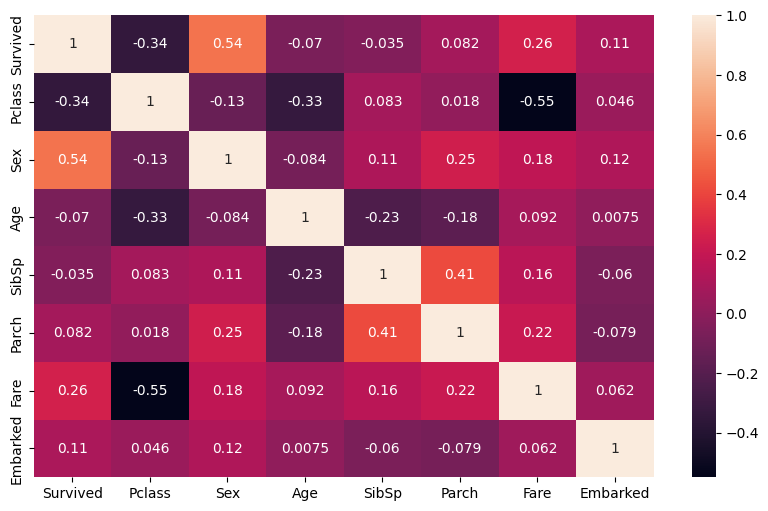

In [25]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True)

plt.show()

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_no_outlier)

X_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])

X_pca.head()

/opt/anaconda3/envs/fod/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/fod/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/fod/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


,PC1,PC2
0,1.231815,-0.345638
1,-2.258577,0.901525
2,0.447173,0.809022
3,-2.038379,0.325509
4,0.899097,-0.957600


In [27]:
pca.explained_variance_ratio_

array([0.28280681, 0.24173971])

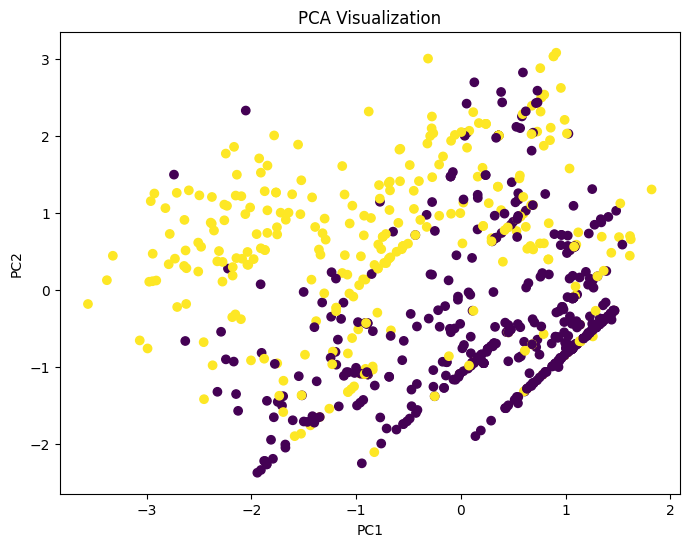

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca['PC1'], X_pca['PC2'], c=y_no_outlier)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("PCA Visualization")

plt.show()